In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update('jax_platform_name', 'cpu')

import pickle 
# import os

import numpy as np

import matplotlib.pyplot as plt
import loco_mujoco.evaluation.evaluation_prosthesis as eval_pros

import importlib
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

# from loco_mujoco.evaluation.evaluation_prosthesis import PostProcessMetricsHandler
# import importlib

# postprocess_handler = PostProcessMetricsHandler()

# importlib.reload(importlib.import_module("evaluation_prosthesis"))

# postprocess_handler = PostProcessMetricsHandler()


In [5]:
# Read all traj data from file
file_name = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/all_trajs_walk_SkeletonMuscle.pkl"
# Load data from file_name: 
with open(file_name, "rb") as f:
    all_trajs = pickle.load(f)
    # print(f"Loaded data: {all_trajs[0]}")

Joint names: ['root', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r', 'hip_flexion_l', 'hip_adduction_l', 'hip_rotation_l', 'knee_angle_l', 'lumbar_extension', 'lumbar_bending', 'lumbar_rotation', 'arm_flex_r', 'arm_add_r', 'arm_rot_r', 'elbow_flex_r', 'pro_sup_r', 'wrist_flex_r', 'wrist_dev_r', 'arm_flex_l', 'arm_add_l', 'arm_rot_l', 'elbow_flex_l', 'pro_sup_l', 'wrist_flex_l', 'wrist_dev_l']
Joint data (qpos/qvel) for baseline joints with side (_l/_r):
hip_flexion_r: qpos shape (88000,), qvel shape (88000,)
knee_angle_r: qpos shape (88000,), qvel shape (88000,)
ankle_angle_r: qpos shape (88000,), qvel shape (88000,)


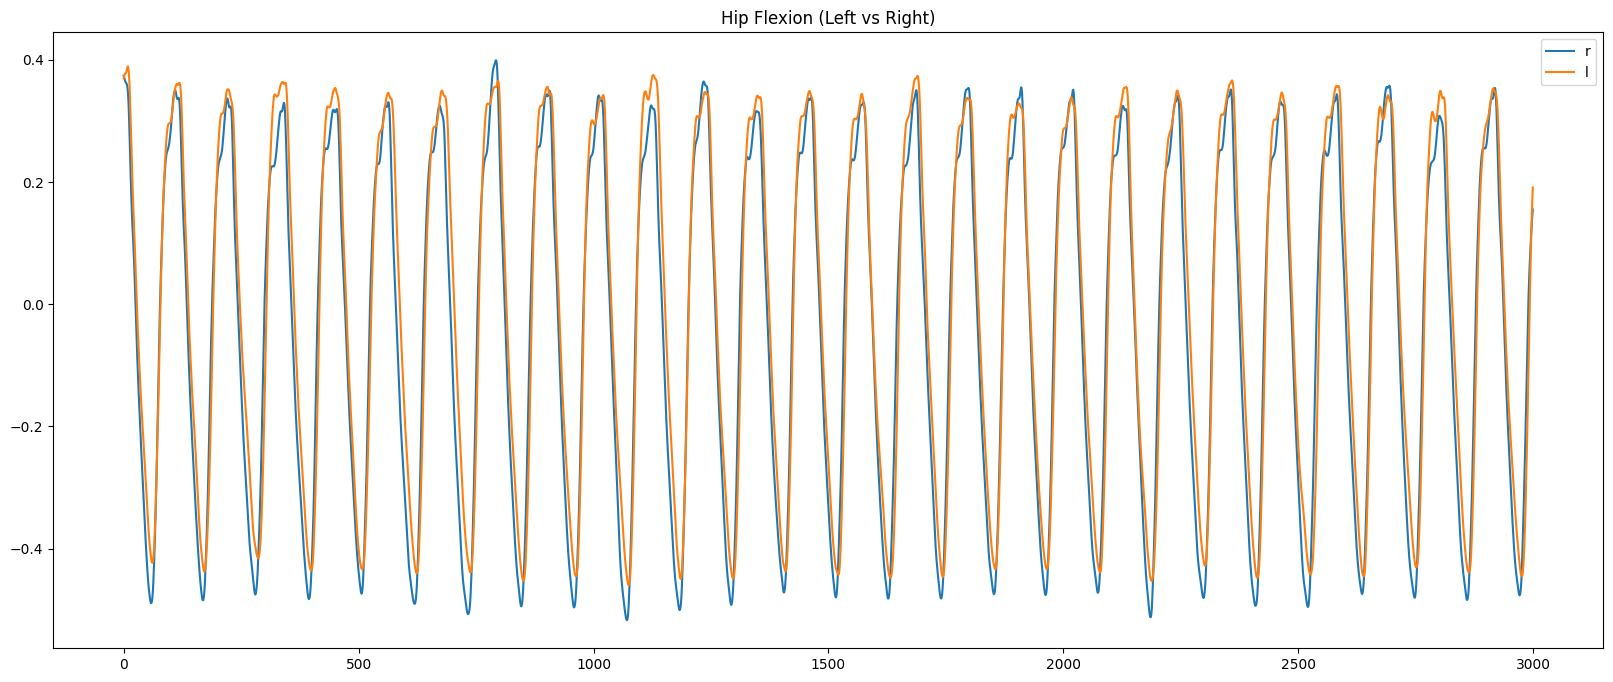

In [38]:
# # Get joint names from the first trajectory's info
joint_names = all_trajs[0].info.joint_names
print("Joint names:", joint_names)
qpos = all_trajs[0].data.qpos
baseline_joint_names = ['hip_flexion', 'knee_angle', 'ankle_angle', 'subtalar_angle', 'mtp_angle']



# Find indices for each joint with side suffix (_l or _r)
joint_indices = {}
for name in baseline_joint_names:
    for suffix in ['_r']: #['_l', '_r']:
        joint_full_name = f"{name}{suffix}"
        if joint_full_name in joint_names:
            joint_indices[joint_full_name] = joint_names.index(joint_full_name)

# Extract qpos and qvel for each joint with side
qvel = all_trajs[0].data.qvel
joint_data_baseline_all = {}
joint_data_baseline = {}
for joint_full_name, idx in joint_indices.items():
    joint_data_baseline[joint_full_name] = {
        'angle': qpos[:, idx+6],
        'velocity': qvel[:, idx+6]
    }
    joint_data_baseline_all[joint_full_name] = {
        'angle': qpos[:, idx+6],
        'velocity': qvel[:, idx+6]
    }

print("Joint data (qpos/qvel) for baseline joints with side (_l/_r):")
for joint_full_name in joint_data_baseline_all:
    print(f"{joint_full_name}: qpos shape {joint_data_baseline_all[joint_full_name]['angle'].shape}, qvel shape {joint_data_baseline_all[joint_full_name]['velocity'].shape}")


# plot hip flexion for left and right
offset = 52
start_inc = 0 
end_inc = 3000 
plt.figure(figsize=(20, 8))

# # Hip
plt.plot(qpos[start_inc:end_inc,7], label='r') #'qpos')
plt.plot(qpos[start_inc+offset:end_inc+offset,12], label='l') #'qpos')

# # # Knee
# plt.plot(qpos[start_inc:end_inc,10], label='r') #'qpos')
# plt.plot(qpos[start_inc+offset:end_inc+offset,15], label='l') #'qpos')

# Ankle
# plt.plot(qpos[start_inc:end_inc,11], label='r') #'qpos')


plt.legend()
# plt.plot(joint_data_baseline_all['hip_flexion_r']['angle'][117:240], label='Left Hip Flexion')
# plt.plot(joint_data_baseline['hip_flexion_l']['angle'][0:500], label='Right Hip Flexion')
# plt.plot(joint_data_baseline_all['knee_angle_r']['angle'][117:240], label='Left Knee flexion')#
# # # plt.plot(joint_data_baseline['knee_angle_l']['angle'][0:500], label='Right Knee flexion')
# plt.plot(joint_data_baseline_all['ankle_angle_r']['angle'][117:240], label='Left Ankle flexion')
# # plt.plot(joint_data_baseline['ankle_angle_l']['angle'][0:500], label='Right Ankle flexion')
plt.title('Hip Flexion (Left vs Right)')

# The original line is not correct and will raise an error.
# If you want to slice all joint angle/velocity arrays for the baseline joints to [117:240], do this:
for joint_full_name in joint_data_baseline_all:
    # Interpolate to length 100 before setting
    angle = joint_data_baseline_all[joint_full_name]['angle'][105:228]* 180 / np.pi  # Convert radians to degrees
    velocity = joint_data_baseline_all[joint_full_name]['velocity'][105:228]* 180 / np.pi  # Convert radians to degrees
    x_old = np.linspace(0, 1, len(angle))
    x_new = np.linspace(0, 1, 100)
    joint_data_baseline[joint_full_name]['angle'] = np.interp(x_new, x_old, angle)
    joint_data_baseline[joint_full_name]['velocity'] = np.interp(x_new, x_old, velocity)

# save joint_data_baseline to a file
with open("/home/nadinebadie/loco-mujoco/prosthesis_test/joint_data_walk_SkeletonMuscle.pkl", "wb") as f:
    pickle.dump(joint_data_baseline, f)

# # Only read joint data from file
# with open("/home/nadinebadie/loco-mujoco/prosthesis_evaluation/joint_data_walk_SkeletonMuscle.pkl", "rb") as f:
#     joint_data_baseline = pickle.load(f)